# **Проектная работа №3. Классификация и детекция объектов на изображении с использованием библиотеки ImageAI**

## **Введение**

До этого момента мы с вами разбирались, как работать с изображениями "вручную" - писали алгоритмы бинаризации, применяли фильтры, операторы Канни и Собеля, выделяли признаки и формировали строгие условия для классификации. В общем, учились понимать структуру изображения без использования машинного обучения. Работали в основном со статичными изображениями.

В данной работе с библиотекой ImageAI - вы воспользуетесь готовыми ML-моделями для детекции и классификации объектов.



**Зачем нам это нужно на данном этапе:**

1. В реальной работе вы часто будете использовать готовые решения - надо уметь с ними работать. Но главное - рассматривайте эту работу как пример того, как нужно формировать свои собственные готовые решения. По сути, ваш алгоритм должен быть упакован как функция, которая получает на вход данные, обрабатывает их и выдает результат обработки - именно так устроены все профессиональные библиотеки.

2. Вы сможете сравнить: что дают классические методы, которые мы программировали, и что дают нейросети. Увидите плюсы и минусы каждого подхода.

3. Научитесь работать не только со статичными изображениями, но и с видеопотоком - обработка видеофайлов, работа с веб-камерой прямо в Colab.

Понимание того, как работают классические алгоритмы, которые мы рассматривали ранее и будем рассматривать в будущем, позволит вам не просто использовать готовые модели как черный ящик, а понимать, что происходит внутри, и когда какой подход лучше применять.


---

Ссылка на страницу с технической документацией: https://imageai.readthedocs.io/en/latest/index.html

- *ImageAI — это Python-библиотека, созданная для того, чтобы дать разработчикам, исследователям и студентам возможность создавать приложения и системы с автономными возможностями глубокого обучения и компьютерного зрения с использованием простого и небольшого количества строк кода.*

**Перечень объектов, которые идентифицирует ImageAI:**

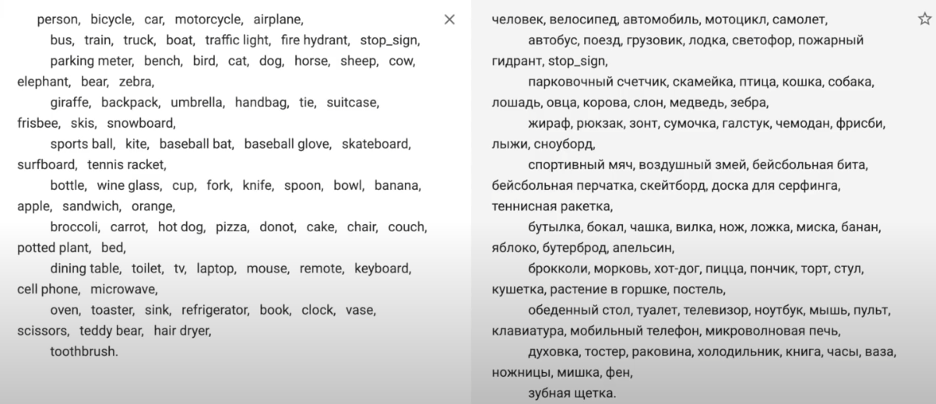

# **Примеры работы с библиотекой:**

In [ ]:
!pip install imageai # установка библиотеки ImageAI

# Добавляем в проект исходное изображение:

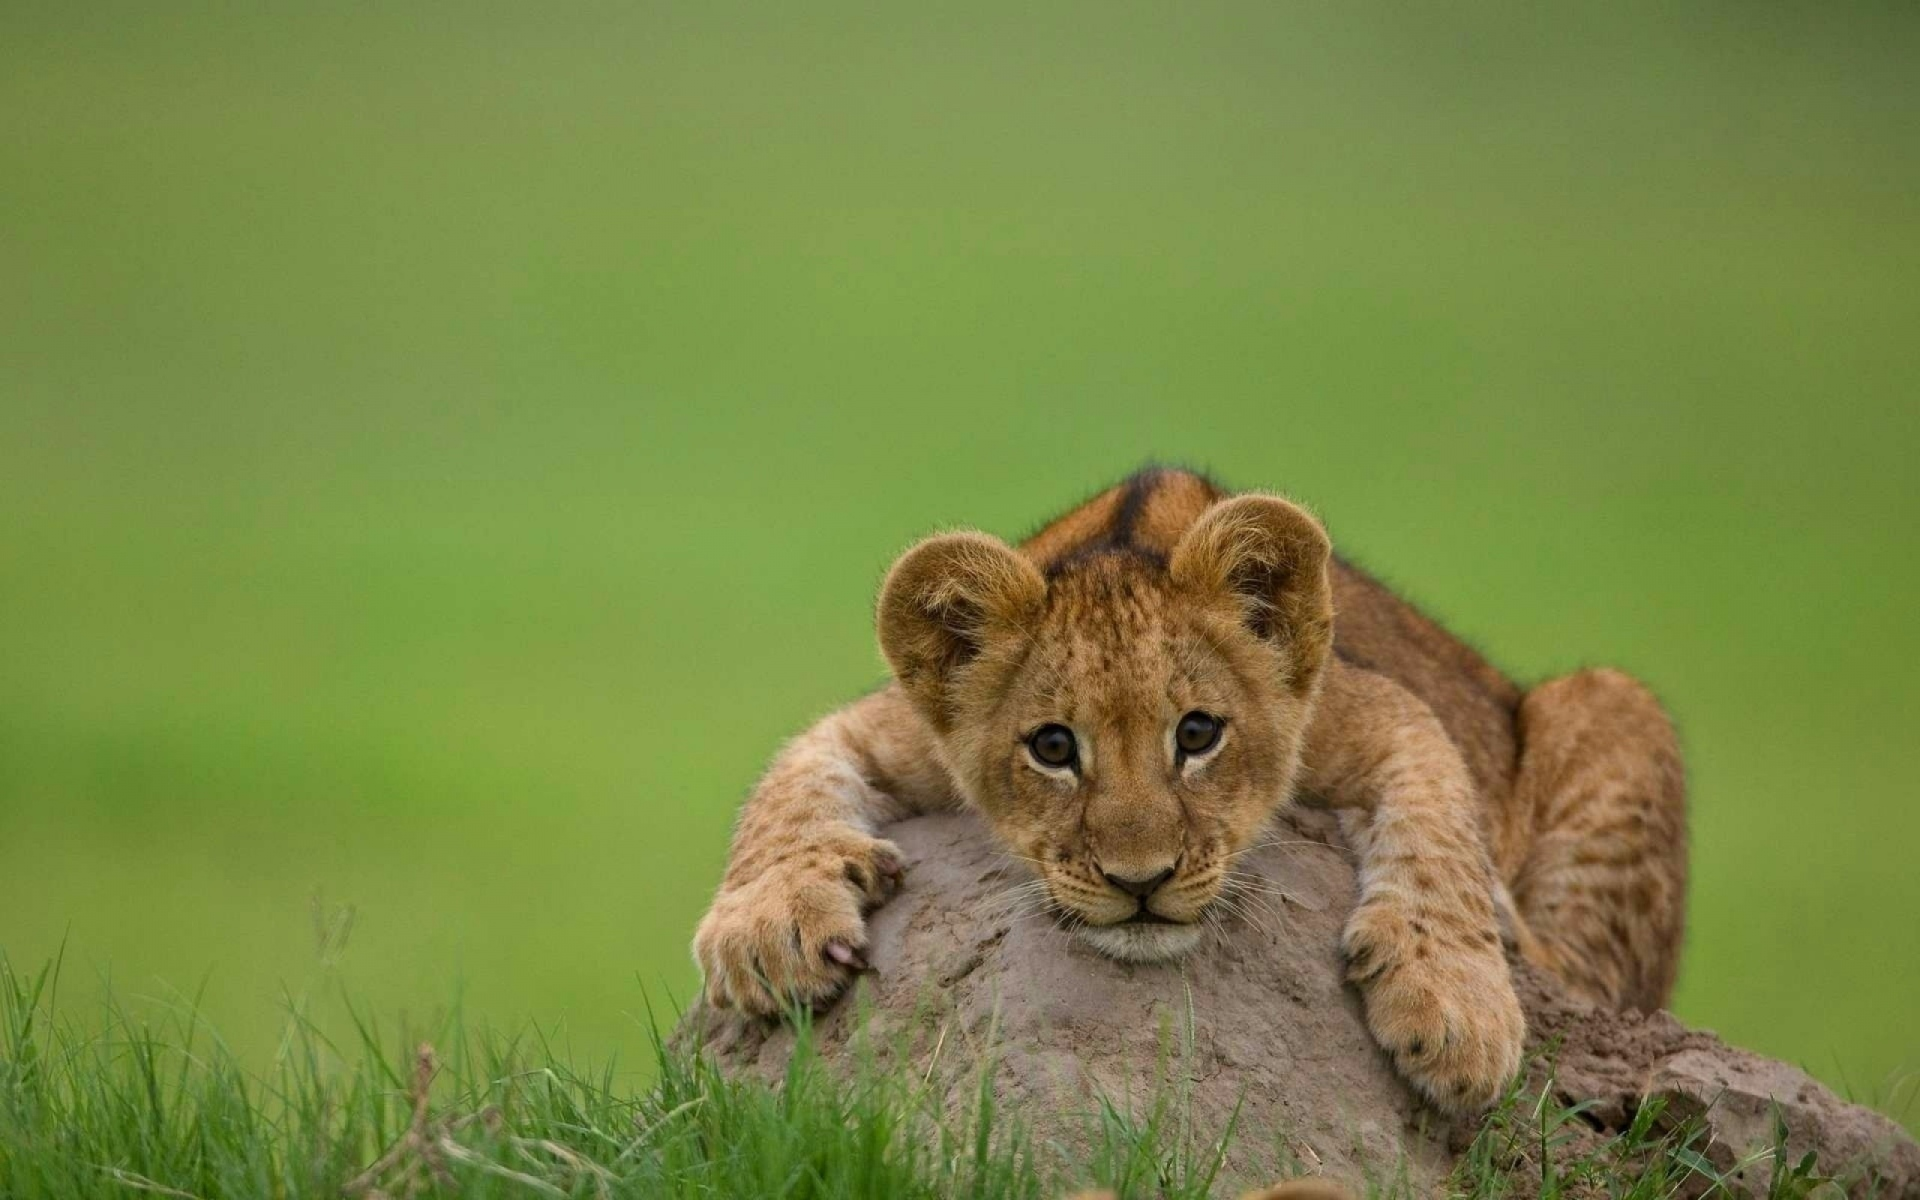

In [ ]:
import numpy as np
import cv2
from google.colab.patches import cv2_imshow
from urllib.request import urlopen
req = urlopen('https://img.youscreen.ru/wall/14977257054998/14977257054998_1920x1200.jpg') # используя метод urlopen, получаем объект запроса по ссылке (изображение)
                                                                                      # и сохраняем его в виде потокового набора данных в переменную "req"

image_2 = np.asarray(bytearray(req.read()), dtype=np.uint8) # преобразуем потоковый набор данных в массив numpy
image_2 = cv2.imdecode(image_2, -1) # декодируем изображение в привычный для отображения формат

cv2_imshow(image_2) # Выводим изображение, используя метод cv2_imshow()

# Пример №1. Детекция

[Техническая документация](https://imageai.readthedocs.io/en/latest/detection/index.html)

In [ ]:
from imageai.Detection import ObjectDetection # Импортируем из библиотеки imageai класс ObjectDetection для поиска объектов
import os # Импортируем библиотеку os для взаимодействия с ОС

exec_path = os.getcwd()# Объявляем переменную exec_path и помещаем в неё функцию os.getcwd()для указания пути к данному проекту (для удобства работы с файлами, находящимися в корневой папке проекта)

detector = ObjectDetection() # создаем объект класса ObjectDetection
detector.setModelTypeAsRetinaNet() # обращаемся к методу setModelTypeAsRetinaNet, тем самым устанавливая для использования в проекте модель RetinaNet для распознавания объектов
detector.setModelPath("/content/retinanet_resnet50_fpn_coco-eeacb38b.pth") # указываем путь к модели (предварительно модель необходимо скачать с официального сайта ImageAI и поместить в корневую папку проекта)
detector.loadModel() # загружаем модель

list = detector.detectObjectsFromImage( # используем метод detectObjectsFromImage для обнаружения объектов на изображении
    input_image=image_2, # указываем путь к исходному изображению, либо имя переменной, которая уже содержит изображение
    output_image_path=os.path.join(exec_path, "new_objects.jpg"), # указываем имя и путь для сохранения распознанного изображения
    minimum_percentage_probability=60, # дополнительная характеристика, отвечающая за процент точности распознавания объекта. В данном случае, если точность объекта будет меньше, чем 60%, то в конечной выборке он присутствовать не будет
    display_percentage_probability=True, # отображение процента точности в конечном изображении
    display_object_name=True # отображение класса объекта в конечном изображении
)

print(list)
output_image = cv2.imread("new_objects.jpg")
cv2_imshow(output_image)

# Пример №2. Классификация

[Техническая документация](https://imageai.readthedocs.io/en/latest/prediction/index.html)

In [ ]:
from imageai.Classification import ImageClassification
import os

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/torchvision/models/inception.py:43: FutureWarning: The default weight initialization of inception_v3 will be changed in future releases of torchvision. If you wish to keep the old behavior (which leads to long initialization times due to scipy/scipy#11299), please set init_weights=True.
  warnings.warn(


In [ ]:
!pip install torch==2.4.0 torchvision==0.19.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 797.2/797.2 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 100.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 97.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 112.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 71.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.2/176.2 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
execution_path = "/content/resnet50-19c8e357.pth"

prediction = ImageClassification()
prediction.setModelTypeAsResNet50()
prediction.setModelPath(execution_path)
prediction.loadModel()

/usr/local/lib/python3.12/dist-packages/imageai/Classification/__init__.py:162: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(self.__model_path)


In [ ]:
predictions, probabilities = prediction.classifyImage((image_2), result_count=10)
for eachPrediction, eachProbability in zip(predictions, probabilities):
    print(eachPrediction , " : " , eachProbability)

snow leopard  :  64.198
Arctic fox  :  12.8115
grey fox  :  5.4439
fox squirrel  :  2.533
cheetah  :  2.2291
cougar  :  2.1936
leopard  :  1.3278
lynx  :  1.2737
lion  :  0.9759
Egyptian cat  :  0.3976


# Задание №1. Детекция объектов на изображении

1.1. Перейдите по ссылке из примера №1

1.2. Загрузите готовую модель для детекции объектов на изображении, отличную от той, что представлена в примере

1.3. Используя данную модель, обработе 5 изображений с большим набором объектов, которые относятся к разным классам

1.4. Визуализируйте полученные результаты

In [ ]:
from imageai.Detection import ObjectDetection
import os
import cv2
from google.colab.patches import cv2_imshow

# Указываем путь к YOLOv3 модели (.h5)
model_path = "/content/yolov3.pt"

# Рабочая директория
exec_path = os.getcwd()

# Создаем детектор
detector = ObjectDetection()
detector.setModelTypeAsYOLOv3()
detector.setModelPath(model_path)
detector.loadModel()

# Выполняем детекцию
detections = detector.detectObjectsFromImage(
    input_image=image_2,
    output_image_path=os.path.join(exec_path, "new_objects.jpg"),
    minimum_percentage_probability=60,
    display_percentage_probability=True,
    display_object_name=True
)

print("✅ Обнаруженные объекты:")
for obj in detections:
    print(f"{obj['name']} : {obj['percentage_probability']:.2f}%")

# Показываем результат
output_image = cv2.imread(os.path.join(exec_path, "new_objects.jpg"))
cv2_imshow(output_image)


In [ ]:
import numpy as np
import cv2
from urllib.request import urlopen
import os
from google.colab.patches import cv2_imshow

urls = [
    'https://avatars.mds.yandex.net/i?id=1eca8679d1970cd760830d2cfd318e16bedd2b45_l-10414173-images-thumbs&n=13',
    'https://www.sbs.com.au/news/sites/sbs.com.au.news/files/Syd%20pedestrians%20-%20Getty.jpg',
    'https://www.sat7uk.org/wp-content/uploads/2021/07/Crowded-Istiklal-Avenue-Istanbul.jpg',
    'https://avatars.mds.yandex.net/i?id=bd92b42ea2c4b01736fdffe1e52664ae_l-10088009-images-thumbs&n=13',
    'https://i.pinimg.com/originals/6d/06/ae/6d06ae9a9a9c561917cbe821997df39e.jpg'
]

exec_path = os.getcwd()

for i, url in enumerate(urls):
    try:
        print(f"🔹 Загружаю изображение {i+1}/{len(urls)} ...")
        req = urlopen(url, timeout=10)
        image_data = np.asarray(bytearray(req.read()), dtype=np.uint8)
        image = cv2.imdecode(image_data, cv2.IMREAD_COLOR)

        output_path = os.path.join(exec_path, f"output{i}.jpg")

        detections = detector.detectObjectsFromImage(
            input_image=image,
            output_image_path=output_path,
            minimum_percentage_probability=60,
            display_percentage_probability=True,
            display_object_name=True
        )

        print("✅ Найдено объектов:", len(detections))
        output_image = cv2.imread(output_path)
        cv2_imshow(output_image)

    except Exception as e:
        print(f"❌ Ошибка при загрузке {url}: {e}")


# Задание №2. Классификация изображений

2.1. Перейдите по ссылке из примера №2

2.2. Загрузите готовую модель для классификации изображений, отличную от той, что представлена в примере

2.3. Используя данную модель, обработе 5 изображений, которые относятся к разным классам

2.4. Сохраните полученные предсказания используемой модели

In [ ]:
prediction = ImageClassification()
prediction.setModelTypeAsInceptionV3()
prediction.setModelPath("/content/inception_v3_google-1a9a5a14.pth")
prediction.loadModel()

In [ ]:
# --- Список изображений ---
urls = [
    'https://pic.rutubelist.ru/video/2025-08-01/13/51/13514ca887092c87ca87636896bdc6ea.jpg',
    'https://vehicle-images.dealerinspire.com/cdaf-110008689/thumbnails/large/1FA6P8CF8S5402512/a1acb198906e6daaa3fde62fc36d2bb0.jpg',
    'https://avatars.mds.yandex.net/i?id=a42be3fd72f50e0a50fda7ac03dd4fb5_l-10811696-images-thumbs&n=13',
    'https://aif-s3.aif.ru/images/015/573/91c0d7c133aa580e0c368bb536b053a1.jpg',
    'https://langformula.ru/wp-content/uploads/2019/04/house.jpg'
]

# --- Классификация и сохранение результатов ---
output_file = os.path.join(execution_path, "output2.txt")

for i, url in enumerate(urls):
    try:
        print(f"🔹 [{i+1}/{len(urls)}] Загружаю изображение...")

        # Скачиваем изображение
        req = urlopen(url, timeout=10)
        image_data = np.asarray(bytearray(req.read()), dtype=np.uint8)
        image = cv2.imdecode(image_data, cv2.IMREAD_COLOR)

        # Сохраняем временный файл для классификации
        temp_path = os.path.join(execution_path, f"temp_image_{i}.jpg")
        cv2.imwrite(temp_path, image)

        # Классификация
        predictions, probabilities = prediction.classifyImage(temp_path, result_count=10)

        # Запись в файл
        with open(output_file, "a") as file:
            file.write(f"{url}\n")
            for p, prob in zip(predictions, probabilities):
                file.write(f"{p} : {prob:.2f}%\n")
            file.write("\n")

        print("✅ Готово")

    except Exception as e:
        with open(output_file, "a") as file:
            file.write(f"{url}\nОшибка: {e}\n\n")
        print(f"❌ Ошибка при обработке {url}: {e}")

print("🎉 Все результаты сохранены в output2.txt")


🔹 [1/5] Загружаю изображение...
✅ Готово
🔹 [2/5] Загружаю изображение...
✅ Готово
🔹 [3/5] Загружаю изображение...
✅ Готово
🔹 [4/5] Загружаю изображение...
✅ Готово
🔹 [5/5] Загружаю изображение...
✅ Готово
🎉 Все результаты сохранены в output2.txt


# Задание №3. Детекция и трекинг объектов на видеопотоке

## 3.1. Подготовка набора данных:

* Найдите и загрузите из сети Интернет 5 видеофайлов с большим количеством разнородных объектов в кадре (например запись с камеры видеонаблюдения на шоссе и тд) длительностью от 30 секунд до 1 минуты (Также Вы можете скачать видеофайл большей длительности, а затем обрезать его в одном из [онлйан-сервисов](https://online-video-cutter.com/ru/?ysclid=lfjb8zk8er484677266).


* Для более оптимальной работы с видеофайлами, сожмите их, используя онлайн-сервисы. ([Например тут](https://compress-video-online.com/ru/ ))

## 3.2. Детекция и трекинг объектов на видеопотоке

3.2.1. [Ознакомьтесь с технической документацией](https://imageai.readthedocs.io/en/latest/video/index.html)

3.2.2. Загрузите готовую модель для детекции объектов

3.2.3. Используя данную модель, обработайте 5 видеофайлов (см. п. 3.1.)

3.2.4. Сохраните полученные видеофайлы

In [ ]:
from imageai.Detection import VideoObjectDetection

detector = VideoObjectDetection()
detector.setModelTypeAsTinyYOLOv3()
detector.setModelPath(os.path.join(exec_path , "/content/tiny-yolov3.pt"))
detector.loadModel()

In [ ]:
exec_path_video = os.path.join(exec_path, '/content/drive/MyDrive/work 4/videos')

video_path = detector.detectObjectsFromVideo(
input_file_path=os.path.join(execution_path, "/content/videous/v (1).mp4"),
output_file_path=os.path.join(execution_path, "/content/videous/video(1)_output"),
frames_per_second=20,
log_progress=True)

Processing Frame :  1
Processing Frame :  2
Processing Frame :  3
Processing Frame :  4
Processing Frame :  5
Processing Frame :  6
Processing Frame :  7
Processing Frame :  8
Processing Frame :  9
Processing Frame :  10
Processing Frame :  11
Processing Frame :  12
Processing Frame :  13
Processing Frame :  14
Processing Frame :  15
Processing Frame :  16
Processing Frame :  17
Processing Frame :  18
Processing Frame :  19
Processing Frame :  20
Processing Frame :  21
Processing Frame :  22
Processing Frame :  23
Processing Frame :  24
Processing Frame :  25
Processing Frame :  26
Processing Frame :  27
Processing Frame :  28
Processing Frame :  29
Processing Frame :  30
Processing Frame :  31
Processing Frame :  32
Processing Frame :  33
Processing Frame :  34
Processing Frame :  35
Processing Frame :  36
Processing Frame :  37
Processing Frame :  38
Processing Frame :  39
Processing Frame :  40
Processing Frame :  41
Processing Frame :  42
Processing Frame :  43
Processing Frame :  

In [ ]:
video_path = detector.detectObjectsFromVideo(
input_file_path=os.path.join(execution_path, "/content/videous/v (2).mp4"),
output_file_path=os.path.join(execution_path, "/content/videous/video(2)_output"),
frames_per_second=20,
log_progress=True)

Processing Frame :  1
Processing Frame :  2
Processing Frame :  3
Processing Frame :  4
Processing Frame :  5
Processing Frame :  6
Processing Frame :  7
Processing Frame :  8
Processing Frame :  9
Processing Frame :  10
Processing Frame :  11
Processing Frame :  12
Processing Frame :  13
Processing Frame :  14
Processing Frame :  15
Processing Frame :  16
Processing Frame :  17
Processing Frame :  18
Processing Frame :  19
Processing Frame :  20
Processing Frame :  21
Processing Frame :  22
Processing Frame :  23
Processing Frame :  24
Processing Frame :  25
Processing Frame :  26
Processing Frame :  27
Processing Frame :  28
Processing Frame :  29
Processing Frame :  30
Processing Frame :  31
Processing Frame :  32
Processing Frame :  33
Processing Frame :  34
Processing Frame :  35
Processing Frame :  36
Processing Frame :  37
Processing Frame :  38
Processing Frame :  39
Processing Frame :  40
Processing Frame :  41
Processing Frame :  42
Processing Frame :  43
Processing Frame :  

In [ ]:
video_path = detector.detectObjectsFromVideo(
input_file_path=os.path.join(execution_path, "/content/videous/v (3).mp4"),
output_file_path=os.path.join(execution_path, "/content/videous/video(3)_output"),
frames_per_second=20,
log_progress=True)

Processing Frame :  1
Processing Frame :  2
Processing Frame :  3
Processing Frame :  4
Processing Frame :  5
Processing Frame :  6
Processing Frame :  7
Processing Frame :  8
Processing Frame :  9
Processing Frame :  10
Processing Frame :  11
Processing Frame :  12
Processing Frame :  13
Processing Frame :  14
Processing Frame :  15
Processing Frame :  16
Processing Frame :  17
Processing Frame :  18
Processing Frame :  19
Processing Frame :  20
Processing Frame :  21
Processing Frame :  22
Processing Frame :  23
Processing Frame :  24
Processing Frame :  25
Processing Frame :  26
Processing Frame :  27
Processing Frame :  28
Processing Frame :  29
Processing Frame :  30
Processing Frame :  31
Processing Frame :  32
Processing Frame :  33
Processing Frame :  34
Processing Frame :  35
Processing Frame :  36
Processing Frame :  37
Processing Frame :  38
Processing Frame :  39
Processing Frame :  40
Processing Frame :  41
Processing Frame :  42
Processing Frame :  43
Processing Frame :  

In [ ]:
video_path = detector.detectObjectsFromVideo(
input_file_path=os.path.join(execution_path, "/content/videous/v (4).mp4"),
output_file_path=os.path.join(execution_path, "/content/videous/video(4)_output"),
frames_per_second=20,
log_progress=True)

Processing Frame :  1
Processing Frame :  2
Processing Frame :  3
Processing Frame :  4
Processing Frame :  5
Processing Frame :  6
Processing Frame :  7
Processing Frame :  8
Processing Frame :  9
Processing Frame :  10
Processing Frame :  11
Processing Frame :  12
Processing Frame :  13
Processing Frame :  14
Processing Frame :  15
Processing Frame :  16
Processing Frame :  17
Processing Frame :  18
Processing Frame :  19
Processing Frame :  20
Processing Frame :  21
Processing Frame :  22
Processing Frame :  23
Processing Frame :  24
Processing Frame :  25
Processing Frame :  26
Processing Frame :  27
Processing Frame :  28
Processing Frame :  29
Processing Frame :  30
Processing Frame :  31
Processing Frame :  32
Processing Frame :  33
Processing Frame :  34
Processing Frame :  35
Processing Frame :  36
Processing Frame :  37
Processing Frame :  38
Processing Frame :  39
Processing Frame :  40
Processing Frame :  41
Processing Frame :  42
Processing Frame :  43
Processing Frame :  

In [ ]:
video_path = detector.detectObjectsFromVideo(
input_file_path=os.path.join(execution_path, "/content/videous/v (5).mp4"),
output_file_path=os.path.join(execution_path, "/content/videous/video(5)_output"),
frames_per_second=20,
log_progress=True)

Processing Frame :  1
Processing Frame :  2
Processing Frame :  3
Processing Frame :  4
Processing Frame :  5
Processing Frame :  6
Processing Frame :  7
Processing Frame :  8
Processing Frame :  9
Processing Frame :  10
Processing Frame :  11
Processing Frame :  12
Processing Frame :  13
Processing Frame :  14
Processing Frame :  15
Processing Frame :  16
Processing Frame :  17
Processing Frame :  18
Processing Frame :  19
Processing Frame :  20
Processing Frame :  21
Processing Frame :  22
Processing Frame :  23
Processing Frame :  24
Processing Frame :  25
Processing Frame :  26
Processing Frame :  27
Processing Frame :  28
Processing Frame :  29
Processing Frame :  30
Processing Frame :  31
Processing Frame :  32
Processing Frame :  33
Processing Frame :  34
Processing Frame :  35
Processing Frame :  36
Processing Frame :  37
Processing Frame :  38
Processing Frame :  39
Processing Frame :  40
Processing Frame :  41
Processing Frame :  42
Processing Frame :  43
Processing Frame :  

# Задание №4. Работа с видеопотоком вебкамеры

## 4.1. Ознакомиться с примерами создания фото и видео в среде Google Colab:



### **Устаналиваем зависимости:**

In [ ]:
# Импортируем необходимые библиотеки
import cv2  # OpenCV для обработки изображений
from google.colab import output  # Для взаимодействия с выводом в Google Colab
from google.colab.patches import cv2_imshow  # Специальная функция для отображения изображений в Colab
from IPython.display import display, Javascript  # Для выполнения JavaScript в ячейках Jupyter
from base64 import b64decode  # Для декодирования данных из base64
import numpy as np  # Для работы с массивами
import time  # Для работы со временем

### **Функция для создания фото:**

In [ ]:
def take_photo(filename='photo.jpg', quality=0.8):
    """
    Захватывает фотографию с веб-камеры пользователя и сохраняет ее в файл.

    Эта функция использует JavaScript для доступа к веб-камере через браузер,
    отображает видеопоток и позволяет пользователю сделать снимок, нажав кнопку "Capture".

    Параметры:
    filename (str): Имя файла для сохранения фотографии. По умолчанию 'photo.jpg'.
    quality (float): Качество сжатия JPEG от 0 до 1. По умолчанию 0.8.

    Возвращает:
    str: Имя файла, в который была сохранена фотография.

    Примечания:
    - Функция требует разрешения пользователя на доступ к веб-камере.
    - Работает только в среде, поддерживающей выполнение JavaScript (например, Google Colab).
    - Изображение сначала кодируется в формат base64, а затем декодируется и сохраняется как файл.
    """
    # Создаем JavaScript-код для захвата фото с веб-камеры
    js = Javascript('''
        async function takePhoto() {
            // Создаем элементы интерфейса
            const div = document.createElement('div');
            const capture = document.createElement('button');
            capture.textContent = 'Capture';
            div.appendChild(capture);
            const video = document.createElement('video');
            video.style.display = 'block';

            // Получаем доступ к веб-камере
            const stream = await navigator.mediaDevices.getUserMedia({video: true});
            document.body.appendChild(div);
            div.appendChild(video);
            video.srcObject = stream;
            await video.play();

            // Изменяем размер вывода, чтобы вместить видео
            google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

            // Ждем, пока пользователь нажмет кнопку "Capture"
            await new Promise((resolve) => capture.onclick = resolve);

            // Создаем canvas и захватываем кадр с видео
            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            canvas.getContext('2d').drawImage(video, 0, 0);

            // Останавливаем видеопоток и удаляем элементы интерфейса
            stream.getVideoTracks()[0].stop();
            div.remove();

            // Возвращаем изображение в формате base64
            return canvas.toDataURL('image/jpeg', %f);
        }
        ''' % quality)

    # Отображаем JavaScript-код
    display(js)

    # Выполняем функцию takePhoto() и получаем результат
    data = output.eval_js('takePhoto()')

    # Декодируем данные из base64
    binary = b64decode(data.split(',')[1])

    # Сохраняем изображение в файл
    with open(filename, 'wb') as f:
        f.write(binary)

    return filename

### **Функция для создания видео:**

In [ ]:
def record_video(filename='video.mp4', duration=5):
    """
    Записывает видео с веб-камеры пользователя и сохраняет его в файл.

    Эта функция использует JavaScript для доступа к веб-камере через браузер,
    записывает видео указанной продолжительности и сохраняет его в формате MP4.

    Параметры:
    filename (str): Имя файла для сохранения видео. По умолчанию 'video.mp4'.
    duration (int): Продолжительность записи в секундах. По умолчанию 5 секунд.

    Возвращает:
    str: Имя файла, в который было сохранено видео.

    Примечания:
    - Функция требует разрешения пользователя на доступ к веб-камере.
    - Работает только в среде, поддерживающей выполнение JavaScript (например, Google Colab).
    - Видео сначала кодируется в формат base64, а затем декодируется и сохраняется как файл MP4.
    - Запись начинается автоматически и заканчивается после указанной продолжительности.
    """
    # Создаем JavaScript-код для записи видео с веб-камеры
    js = Javascript('''
        async function recordVideo(duration) {
            // Создаем элемент видео
            const video = document.createElement('video');
            video.style.display = 'block';

            // Получаем доступ к веб-камере
            const stream = await navigator.mediaDevices.getUserMedia({video: true});
            document.body.appendChild(video);
            video.srcObject = stream;
            await video.play();

            // Изменяем размер вывода, чтобы вместить видео
            google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

            // Создаем объект MediaRecorder для записи видео
            const recorder = new MediaRecorder(stream);
            const chunks = [];
            recorder.ondataavailable = e => chunks.push(e.data);
            recorder.start();

            // Ждем указанную продолжительность
            await new Promise(resolve => setTimeout(resolve, duration * 1000));

            // Останавливаем запись и видеопоток
            recorder.stop();
            stream.getVideoTracks()[0].stop();
            video.remove();

            // Возвращаем записанное видео в формате base64
            return new Promise(resolve => {
                recorder.onstop = () => {
                    const blob = new Blob(chunks, {type: 'video/mp4'});
                    const reader = new FileReader();
                    reader.onload = e => resolve(e.target.result);
                    reader.readAsDataURL(blob);
                };
            });
        }
    ''')

    # Отображаем JavaScript-код
    display(js)

    # Выполняем функцию recordVideo() и получаем результат
    data = output.eval_js(f'recordVideo({duration})')

    # Декодируем данные из base64
    binary = b64decode(data.split(',')[1])

    # Сохраняем видео в файл
    with open(filename, 'wb') as f:
        f.write(binary)

    return filename

### **Пример работы:**

In [ ]:
photo_filename = take_photo()

<IPython.core.display.Javascript object>

In [ ]:
# Сделать фото
photo_filename = take_photo()

# Записать видео длительностью 10 секунд
video_filename = record_video(duration=10)

<IPython.core.display.Javascript object>

MessageError: NotReadableError: Could not start video source

In [ ]:
# Записать видео длительностью 10 секунд
video_filename = record_video(duration=10)

<IPython.core.display.Javascript object>

## 4.2. Детекция и трекинг объектов на видеопотоке с вебкамеры


### 4.2.1. Используйте take_photo() для получения снимка и record_video() для создания 5-10 секундного видео с веб-камеры


### 4.2.2. Загрузите модель трекинга и детекции объектов


In [ ]:
from imageai.Detection import VideoObjectDetection
import os # Импортируем библиотеку os для взаимодействия с ОС

exec_path = os.getcwd()# Объявляем переменную exec_path и помещаем в неё функцию os.getcwd()для указания пути к данному проекту (для удобства работы с файлами, находящимися в корневой папке проекта)

detector = ObjectDetection()
detector.setModelTypeAsTinyYOLOv3()
detector.setModelPath(os.path.join(exec_path , "/content/tiny-yolov3.pt"))
detector.loadModel()

### 4.2.3. Реализуйте функции для обработки полученных фото и видео с помощью модели трекинга:
- Для фото: сохраните результат как "tracked_photo.jpg".
- Для видео: создайте новое видео с отмеченными объектами - "tracked_video.mp4".

In [ ]:
from imageai.Detection import ObjectDetection, VideoObjectDetection

In [ ]:
from imageai.Detection import ObjectDetection, VideoObjectDetection
import os

exec_path = os.getcwd()
model_path = os.path.join(exec_path, "/content/tiny-yolov3.pt")


def process_photo(input_photo_path):
    """Детекция объектов на фото, сохраняет результат как tracked_photo3.jpg"""
    detector = ObjectDetection()
    detector.setModelTypeAsTinyYOLOv3()
    detector.setModelPath(model_path)
    detector.loadModel()

    output_photo_path = os.path.join(exec_path, "tracked_photo3.jpg")

    detections = detector.detectObjectsFromImage(
        input_image=input_photo_path,
        output_image_path=output_photo_path,
        minimum_percentage_probability=40
    )

    for obj in detections:
        print(f"{obj['name']} : {obj['percentage_probability']:.2f}%")

    print("Фото сохранено как:", output_photo_path)
    return output_photo_path


def process_video(input_video_path):
    """Детекция и трекинг объектов на видео, сохраняет результат как tracked_video3.mp4"""
    detector = VideoObjectDetection()
    detector.setModelTypeAsTinyYOLOv3()
    detector.setModelPath(model_path)
    detector.loadModel()

    output_video_path = os.path.join(exec_path, "tracked_video3")

    result_path = detector.detectObjectsFromVideo(
        input_file_path=input_video_path,
        output_file_path=output_video_path,
        frames_per_second=20,
        minimum_percentage_probability=40,
        log_progress=True
    )

    print("Видео сохранено как:", result_path)
    return result_path


In [ ]:
# Для фото
process_photo("/content/photo.jpg")

Фото сохранено как: /content/tracked_photo3.jpg


'/content/tracked_photo3.jpg'

In [ ]:
# Для фото
process_photo("/content/photo.jpg")

# Для видео
process_video("/content/video.mp4")


Фото сохранено как: /content/tracked_photo.jpg
Processing Frame :  1
Processing Frame :  2
Processing Frame :  3
Processing Frame :  4
Processing Frame :  5
Processing Frame :  6
Processing Frame :  7
Processing Frame :  8
Processing Frame :  9
Processing Frame :  10
Processing Frame :  11
Processing Frame :  12
Processing Frame :  13
Processing Frame :  14
Processing Frame :  15
Processing Frame :  16
Processing Frame :  17
Processing Frame :  18
Processing Frame :  19
Processing Frame :  20
Processing Frame :  21
Processing Frame :  22
Processing Frame :  23
Processing Frame :  24
Processing Frame :  25
Processing Frame :  26
Processing Frame :  27
Processing Frame :  28
Processing Frame :  29
Processing Frame :  30
Processing Frame :  31
Processing Frame :  32
Processing Frame :  33
Processing Frame :  34
Processing Frame :  35
Processing Frame :  36
Processing Frame :  37
Processing Frame :  38
Processing Frame :  39
Processing Frame :  40
Processing Frame :  41
Processing Frame : 

'/content/tracked_video.mp4'

In [ ]:
!ls -lh /content/photo.jpg

-rw-r--r-- 1 root root 26K Oct 26 12:33 /content/photo.jpg


In [ ]:
!find /content -name "tracked_photo*"

In [ ]:
!ls -lh /content

total 38M
-rw-r--r-- 1 root root  26K Oct 26 12:33 photo.jpg
drwxr-xr-x 1 root root 4.0K Oct 23 13:40 sample_data
-rw-r--r-- 1 root root  34M Oct 26 12:21 tiny-yolov3.pt
-rw-r--r-- 1 root root 2.0M Oct 26 12:36 tracked_video.mp4
-rw-r--r-- 1 root root 2.1M Oct 26 12:33 video.mp4
